## Data Feeds
- Exploration of useful data feeds to support downstream decisions
  - Equities, Screeners
  - News
  - Macro-economic

In [ ]:
# Credentials (FRED)
from dotenv import load_dotenv
import os

load_dotenv()

# Data
import pandas as pd

pd.set_option("display.max_columns", None)

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("bright")

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
    }
)

# Financial
from openbb import obb

obb.user.credentials.fred_api_key = os.getenv("FRED_API_KEY")

## OpenBB Routers

## Commodity

- Crude Oil related signals could be useful indicators for energy tickers
  - EIA weekly inventory draw/build → statistically significant edge on energy tickers?
  - **TODO (strategy notebook):** test across XOM, CVX, COP, XLE
  - **TODO (strategy notebook):** check airline names (DAL, UAL): inverse relationship?

In [28]:
df = obb.commodity.petroleum_status_report().to_dataframe()

crude = (
    df[df["symbol"] == "WCESTUS1"][["value"]]
    .rename(columns={"value": "crude_stocks_mbb"})
    .sort_index()
)

crude.tail()

,crude_stocks_mbb
date,
2026-03-20,456185.0
2026-03-27,461636.0
2026-04-03,464717.0
2026-04-10,463804.0
2026-04-17,465729.0


## Economy

Macro indicators used as a **regime overlay** to gate downstream strategies.

| Indicator | What it measures | Regime signal | TODO |
|---|---|---|---|
| Yield curve (10Y-2Y) | Gap between long and short treasury yields | Negative = recession warning; steep = expansion | Test GLD and IWM response at 6m, 12m, 18m lags post-inversion |
| Unemployment (UNRATE) | % of workforce unemployed and actively looking for work | Rising fast = reduce risk; low and stable = risk-on | Implement Sahm Rule trigger and test as portfolio exit signal |
| PCE inflation | Fed's preferred price gauge across all consumer spending | Above 3% = favour value/energy; below 2% = favour growth | Classify PCE regimes and measure forward returns per sector |
| M2 money supply | Total money in circulation (cash, savings, money market) | Growing fast = liquidity rally; shrinking = tighten up | Test whether negative M2 YoY growth predicts equity drawdowns |
| OECD CLI | Forward-looking composite designed to call turning points 6-9 months early | Crossing above 100 = expansion; below 100 = slowdown | Test CLI crossings as entry/exit signal for cyclicals vs defensives |

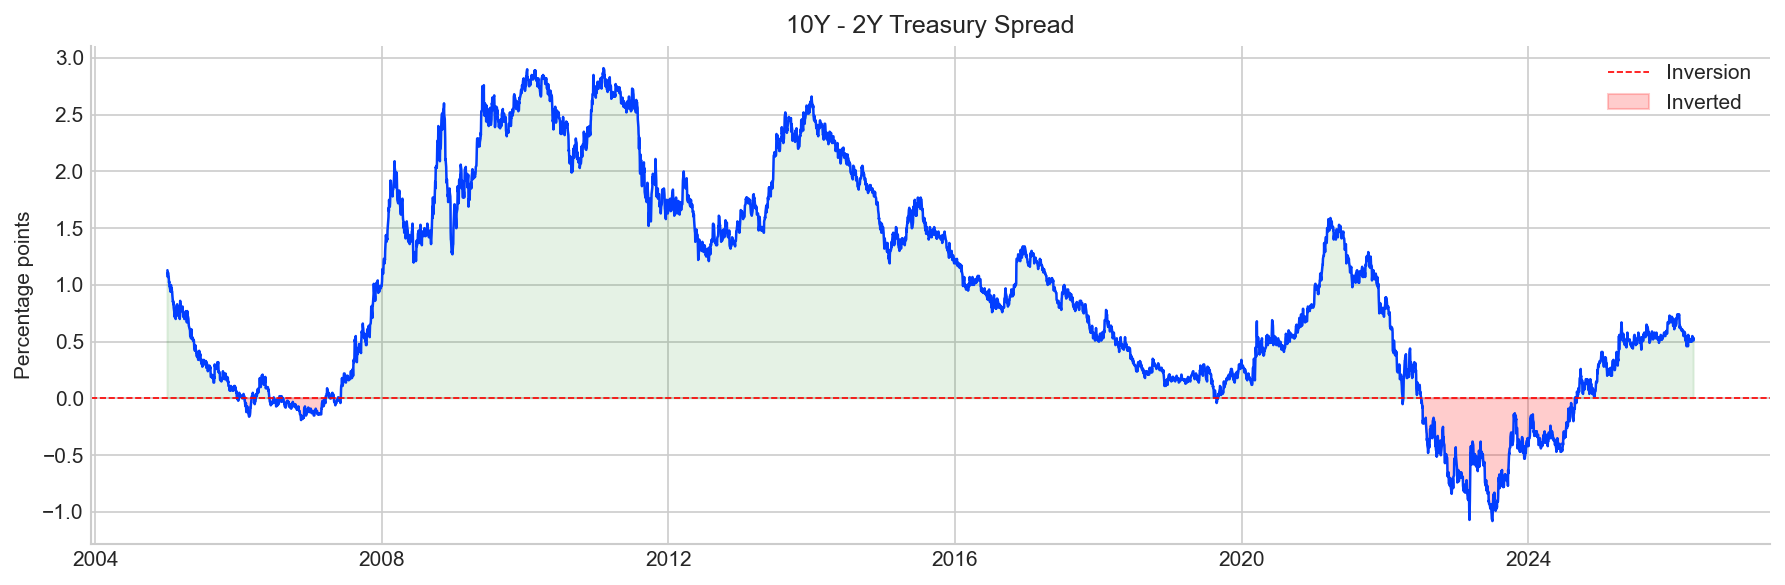

In [ ]:
# TODO: Test as a signal for recession warning, impact on flight to safety assets on a potentially lagged basis
spread = (
    obb.economy.fred_series(symbol="T10Y2Y", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"T10Y2Y": "value"})
)
spread.index = pd.to_datetime(spread.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spread.index, spread["value"], linewidth=1.2)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="Inversion")
ax.fill_between(
    spread.index, spread["value"], 0,
    where=spread["value"] < 0, color="red", alpha=0.2, label="Inverted",
)
ax.fill_between(
    spread.index, spread["value"], 0,
    where=spread["value"] >= 0, color="green", alpha=0.1,
)
ax.set_title("10Y - 2Y Treasury Spread")
ax.set_ylabel("Percentage points")
ax.legend()
plt.tight_layout()

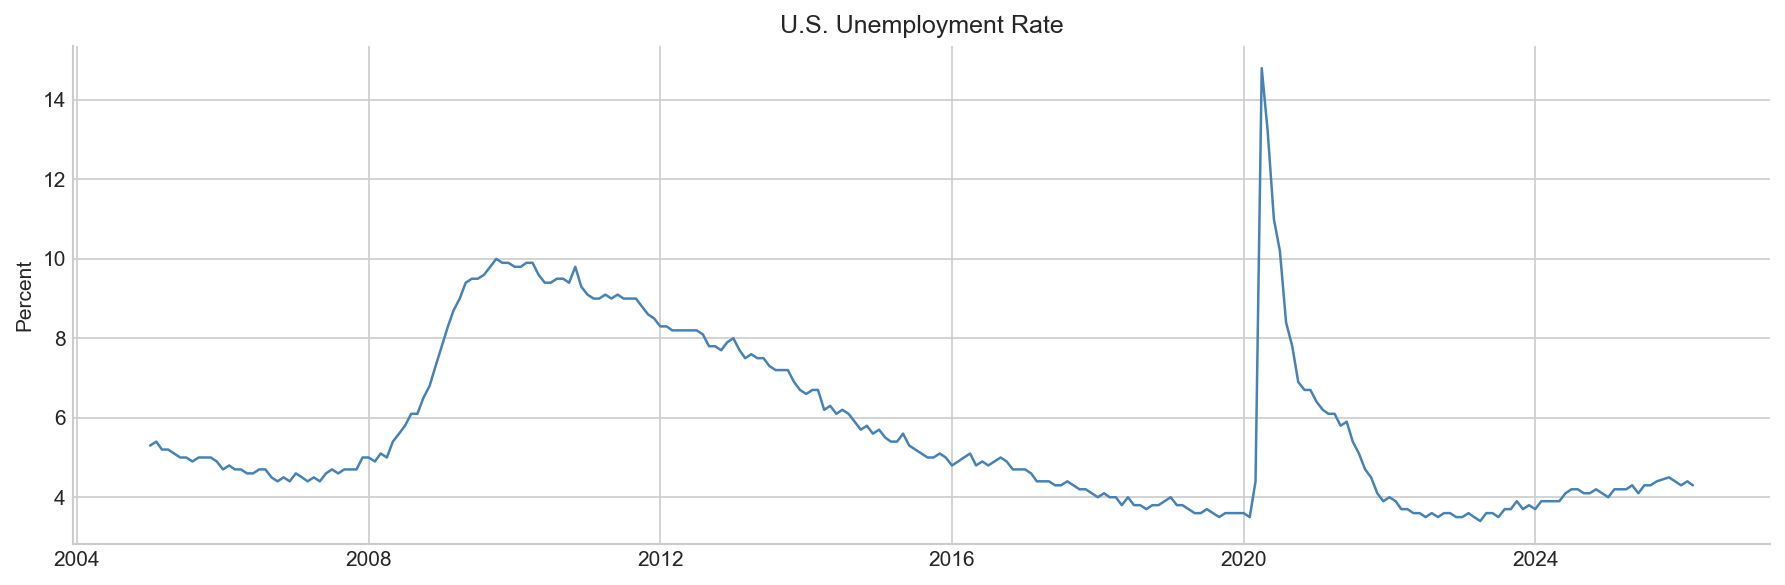

In [ ]:
# TODO: Rising unemployment by 0.5% from its 12-month low (Sahm Rule) as a signal?
unemp = (
    obb.economy.fred_series(symbol="UNRATE", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"UNRATE": "value"})
)
unemp.index = pd.to_datetime(unemp.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(unemp.index, unemp["value"], linewidth=1.2, color="steelblue")
ax.set_title("U.S. Unemployment Rate")
ax.set_ylabel("Percent")
plt.tight_layout()

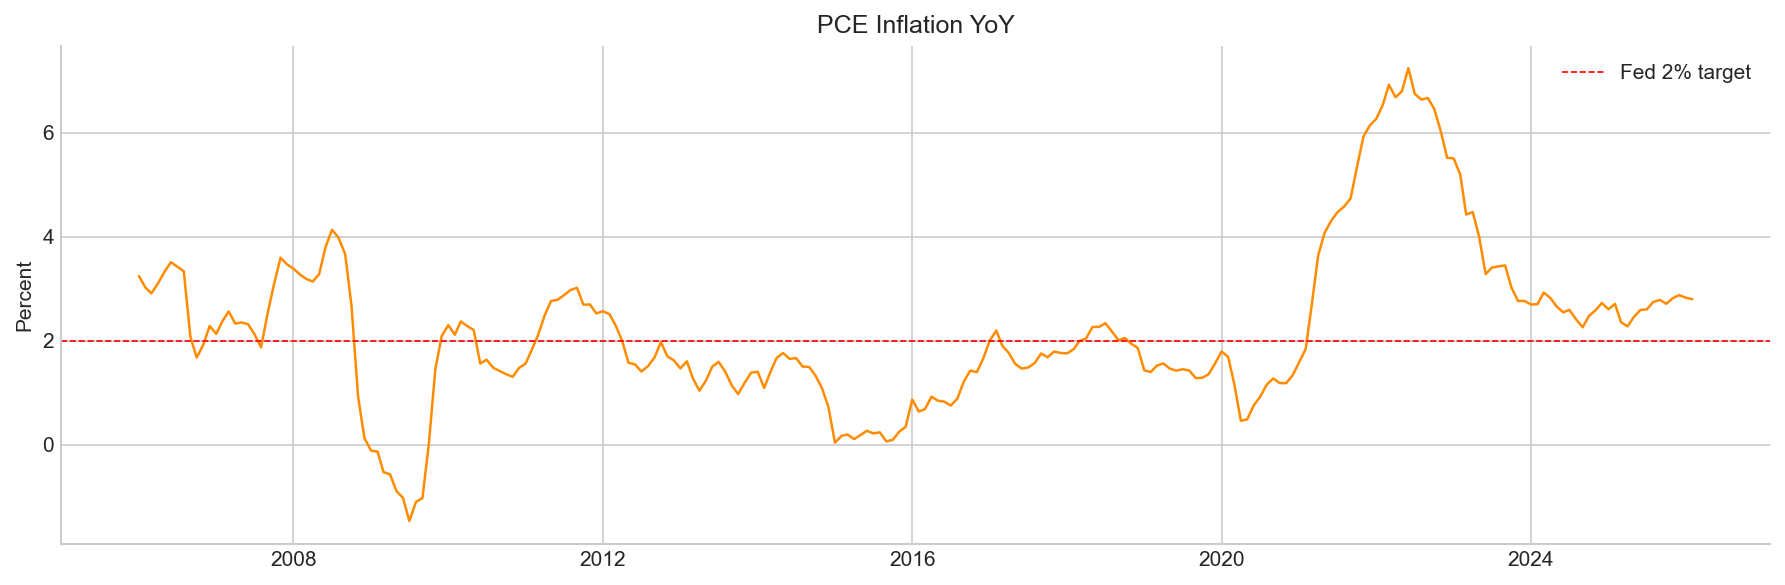

In [ ]:
# TODO: Test PCE as a potential signal for risk-on vs risk-off
pce = (
    obb.economy.fred_series(symbol="PCEPI", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"PCEPI": "value"})
)
pce.index = pd.to_datetime(pce.index)
pce["yoy"] = pce["value"].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pce.index, pce["yoy"], linewidth=1.2, color="darkorange")
ax.axhline(2.0, color="red", linewidth=0.8, linestyle="--", label="Fed 2% target")
ax.set_title("PCE Inflation YoY")
ax.set_ylabel("Percent")
ax.legend()
plt.tight_layout()

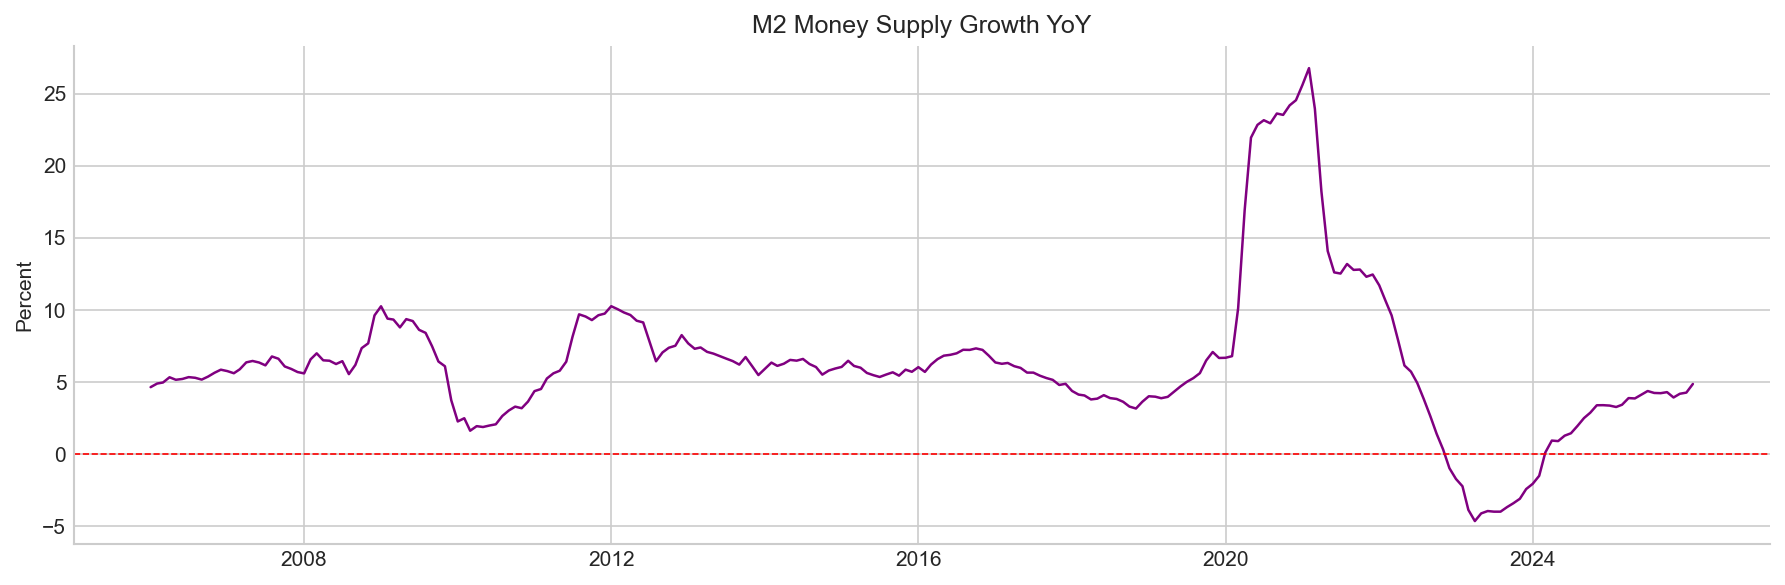

In [ ]:
# TODO: Money supply's impact on equity buying vs. selling
m2 = (
    obb.economy.fred_series(symbol="M2SL", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"M2SL": "value"})
)
m2.index = pd.to_datetime(m2.index)
m2["yoy"] = m2["value"].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(m2.index, m2["yoy"], linewidth=1.2, color="purple")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_title("M2 Money Supply Growth YoY")
ax.set_ylabel("Percent")
plt.tight_layout()

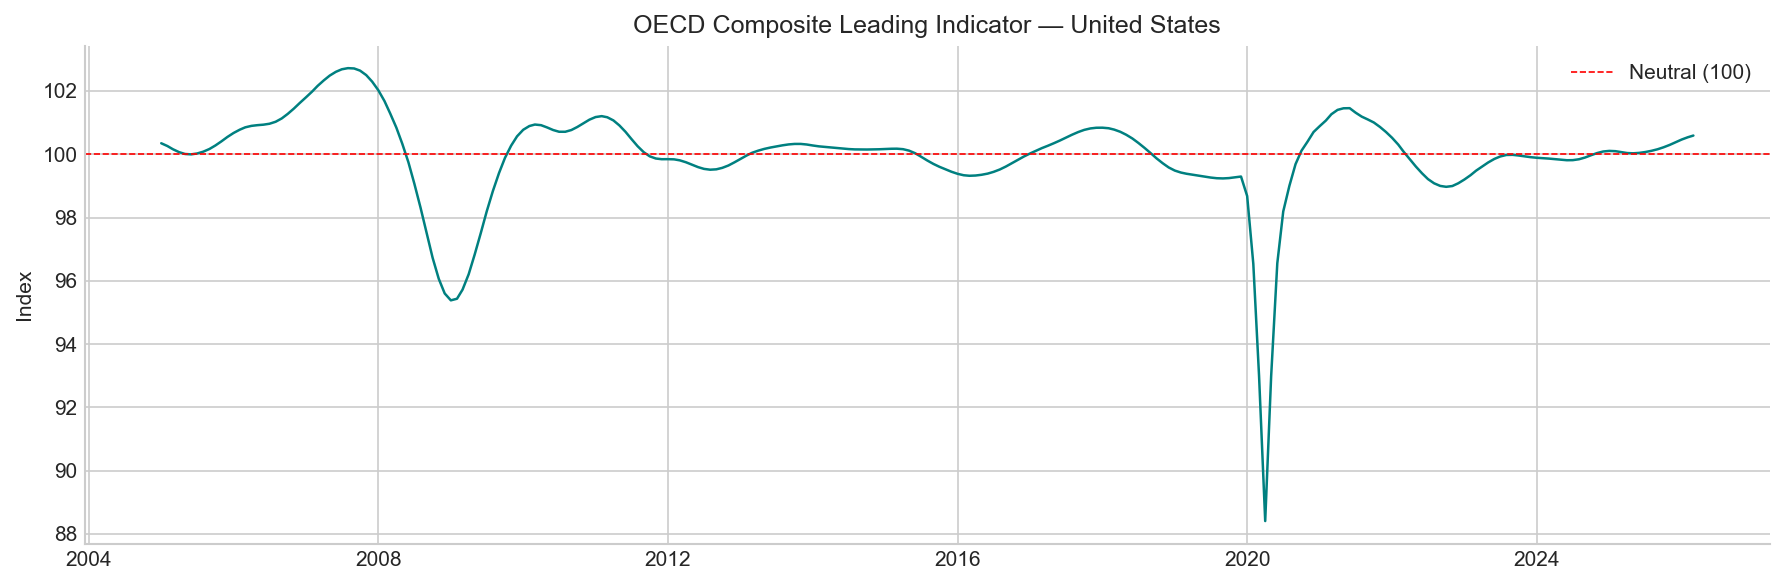

In [ ]:
# TODO: CLI as an indicator for acceleration / deceleration and impact on equities
cli = obb.economy.composite_leading_indicator(start_date="2005-01-01").to_dataframe()
cli.index = pd.to_datetime(cli.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cli.index, cli["value"], linewidth=1.2, color="teal")
ax.axhline(100, color="red", linewidth=0.8, linestyle="--", label="Neutral (100)")
ax.set_title("OECD Composite Leading Indicator — United States")
ax.set_ylabel("Index")
ax.legend()
plt.tight_layout()

## Stock Screener
- Provision a list of tickers to explore as the population

In [4]:
# Stocks from the US exchanges
US_EXCHANGES = {"NMS", "NGM", "NCM", "NYQ", "ASE"}

screener_obj = obb.equity.screener()
tickers = [s.symbol for s in screener_obj.results]
screener_df = obb.equity.screener().to_dataframe()
screener_df = screener_df[screener_df.exchange.isin(US_EXCHANGES)]

# Price Cap
PRICE = 30
screener_df = screener_df.query(f"price > {PRICE}")

# Volume cap
VOLUME_CAP = 30
screener_df = screener_df.nlargest(VOLUME_CAP, columns="volume")
screener_df.sample(10)

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
67,BKR,Baker Hughes Company,68.94,4.45000,0.069003,15359593,66.460,69.8600,65.7600,64.49,61.3518,51.00060,69.86,34.560,6.837176e+10,9.917573e+08,19.086,3.612072,3.13,2.84034,24.271744,0.014266,NMS,America/New_York,2026-04-23 16:00:00-04:00,USD
61,AMKR,"Amkor Technology, Inc.",78.10,5.18999,0.071184,5170072,77.755,79.2100,74.5801,72.91,51.0694,38.18325,79.21,16.540,1.935406e+10,2.478112e+08,18.079,4.319929,1.50,2.29295,34.060930,0.004554,NMS,America/New_York,2026-04-27 16:00:00-04:00,USD
6,AAOI,"Applied Optoelectronics, Inc.",162.17,24.44000,0.177449,13877988,142.120,164.8700,140.0000,137.73,102.8456,48.15855,173.41,11.865,1.259657e+10,7.767512e+07,9.786,16.571632,-0.63,3.19750,50.717747,0.000000,NGM,America/New_York,2026-05-07 16:00:00-04:00,USD
13,AMD,"Advanced Micro Devices, Inc.",347.81,42.48000,0.139128,79942384,336.835,352.9900,334.5400,305.33,221.5738,206.59525,352.99,91.870,5.670732e+11,1.630339e+09,38.650,8.998964,2.61,11.00824,31.595423,0.000000,NMS,America/New_York,2026-05-05 16:00:00-04:00,USD
153,ENTG,"Entegris, Inc.",155.98,6.64999,0.044532,4314231,153.660,159.1500,151.1700,149.33,127.2404,100.06975,159.15,66.320,2.374778e+10,1.522489e+08,26.026,5.993238,1.54,4.43009,35.209217,0.002679,NMS,America/New_York,2026-04-30 08:30:00-04:00,USD
47,ALAB,"Astera Labs, Inc.",212.84,15.30000,0.077453,6644908,203.000,214.2374,202.6150,197.54,134.0652,160.30040,262.90,62.310,3.645565e+10,1.712820e+08,8.013,26.561838,1.21,3.58434,59.380524,0.000000,NMS,America/New_York,2026-05-05 16:00:00-04:00,USD
10,ARM,Arm Holdings plc,234.81,30.20000,0.147598,20236234,221.490,237.6800,218.4550,204.61,141.6537,139.79422,237.68,100.020,2.493679e+11,1.061999e+09,7.343,31.977394,0.75,2.14410,109.514480,0.000000,NMS,America/New_York,2026-05-06 16:00:00-04:00,USD
82,ESI,Element Solutions Inc.,40.34,2.36000,0.062138,4717501,38.290,40.7000,38.2100,37.98,34.6412,28.28125,40.70,19.740,9.826638e+09,2.435954e+08,11.018,3.661282,0.79,2.00091,20.160826,0.008425,NYQ,America/New_York,2026-04-28 16:00:00-04:00,USD
99,EW,Edwards Lifesciences Corporatio,84.15,4.43000,0.055569,11798864,82.500,84.7300,82.4725,79.72,81.6158,80.92385,87.89,72.300,4.851599e+10,5.765417e+08,17.802,4.726997,1.81,3.35979,25.046207,0.000000,NYQ,America/New_York,2026-04-23 16:00:00-04:00,USD
36,NEM,Newmont Corporation,120.70,9.64000,0.086800,10014952,115.010,120.8300,111.6600,111.06,114.7680,94.41175,134.88,48.270,1.288536e+11,1.067553e+09,31.113,3.879407,7.71,10.95493,11.017870,0.009184,NYQ,America/New_York,2026-04-23 16:00:00-04:00,USD
